# Tier 4 vehicle geometry, CG and mass closure verification

Tier 4 adds physical vehicle components that own their geometry, an aircraft
assembly that aggregates mass and CG, and a mass closure written as one explicit
`asb.Opti` equality:

$$m_{TO} = \sum_i m_i\big(m_{TO}, \text{geometry}\big)$$

There is no fixed-point loop: the take-off mass is an Opti variable that feeds
every correlation through the structural design condition. Structures is a mass
model only.

| Piece | Module |
|---|---|
| `StructuralDesignCondition` | `vehicle/condition.py` |
| `Wing`, `HorizontalTail`, `VerticalTail` | `vehicle/surfaces.py` |
| `Fuselage` | `vehicle/fuselage.py` |
| `LandingGear`, `Systems`, `Payload` | `vehicle/items.py` |
| `PowertrainInstallation`, `InstalledInstance` | `vehicle/powertrain_installation.py` |
| `Aircraft`, `MassBreakdown` | `vehicle/aircraft.py` |
| Reference closure | `examples/aircraft_mass_closure.py` |

Geometry is handed to `asb.Wing`/`asb.Fuselage`, masses are AeroSandbox's Raymer
general-aviation correlations (Raymer, *Aircraft Design: A Conceptual Approach*,
5th ed., sec. 15.3.3) and CG aggregation is `asb.MassProperties` addition, so no
formula is duplicated. The configuration is illustrative, not Halo data.

Run from the repo root environment:

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier4_vehicle_mass_closure
```

In [1]:
import ast
import sys
from dataclasses import fields, replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.library.weights.raymer_general_aviation_weights as raymer
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.vehicle.aircraft import MassBreakdown
from aircraft_closure.vehicle.condition import StructuralDesignCondition
from aircraft_closure.vehicle.fuselage import Fuselage
from aircraft_closure.vehicle.items import LandingGear, Payload, Systems
from aircraft_closure.vehicle.surfaces import HorizontalTail, VerticalTail, Wing
from examples.aircraft_mass_closure import build_reference_aircraft, solve_mass_closure

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


condition = StructuralDesignCondition(mass_design_kg=1500.0)
ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. Geometry owned by physical components

Surfaces are unswept trapezoids parameterized by area, aspect ratio and taper.
The component computes span $b = \sqrt{S\,AR}$ and root chord
$c_r = 2S / \big(b(1+\lambda)\big)$; AeroSandbox recovers area, span, aspect
ratio, taper and the mean aerodynamic chord
$\bar c = \tfrac23 c_r (1+\lambda+\lambda^2)/(1+\lambda)$ from the resulting
`asb.Wing`. The vertical tail is one fin with $AR = h^2/S$.

In [2]:
wing = Wing(area_m2=12.0, aspect_ratio=9.0, taper_ratio=0.5)
asb_wing = wing.to_asb()
mac_closed_form_m = 2 / 3 * wing.chord_root_m() * (1 + 0.5 + 0.25) / 1.5
print(f"span {float(asb_wing.span()):.4f} m, root chord {wing.chord_root_m():.4f} m, "
      f"MAC {float(asb_wing.mean_aerodynamic_chord()):.4f} m")
check("geometry: asb wing area = S", close(float(asb_wing.area()), 12.0))
check("geometry: asb span = sqrt(S AR)", close(float(asb_wing.span()), (12 * 9) ** 0.5))
check("geometry: asb aspect ratio recovered", close(float(asb_wing.aspect_ratio()), 9.0))
check("geometry: asb taper ratio recovered", close(float(asb_wing.taper_ratio()), 0.5))
check("geometry: asb MAC = closed-form trapezoid MAC", close(float(asb_wing.mean_aerodynamic_chord()), mac_closed_form_m))
fin = VerticalTail()
check("geometry: vertical tail is a single non-symmetric fin", not fin.to_asb().symmetric)
check("geometry: fin area recovered", close(float(fin.to_asb().area()), fin.area_m2))
fuselage = Fuselage()
asb_fuselage = fuselage.to_asb()
print(f"fuselage length {float(asb_fuselage.length()):.3f} m, wetted area {float(asb_fuselage.area_wetted()):.2f} m2, "
      f"volume {float(asb_fuselage.volume()):.2f} m3")
check("geometry: fuselage length recovered", close(float(asb_fuselage.length()), fuselage.length_m))
cylinder_wetted_m2 = np.pi * fuselage.diameter_m * fuselage.length_m
check("geometry: fuselage wetted area below the enclosing cylinder", float(asb_fuselage.area_wetted()) < cylinder_wetted_m2)

span 10.3923 m, root chord 1.5396 m, MAC 1.1975 m
PASS  geometry: asb wing area = S
PASS  geometry: asb span = sqrt(S AR)
PASS  geometry: asb aspect ratio recovered
PASS  geometry: asb taper ratio recovered
PASS  geometry: asb MAC = closed-form trapezoid MAC
PASS  geometry: vertical tail is a single non-symmetric fin
PASS  geometry: fin area recovered
fuselage length 7.000 m, wetted area 19.64 m2, volume 5.13 m3
PASS  geometry: fuselage length recovered
PASS  geometry: fuselage wetted area below the enclosing cylinder


## 2. Empirical masses are AeroSandbox's correlations

Each component calls the AeroSandbox Raymer function on its own geometry and
multiplies by a calibration `mass_factor` (default 1). Identity checks confirm
nothing was re-implemented; scaling checks confirm the published exponents on
design mass x load factor: wing 0.49, horizontal tail 0.414, vertical tail 0.376.
Raymer's general-aviation scope (light aircraft, order 1000-3000 kg) bounds
where these numbers mean anything.

In [3]:
op_point = condition.operating_point()
check("correlation: wing mass is asb raymer.mass_wing", close(
    float(Wing().get_mass_properties(condition).mass), float(raymer.mass_wing(Wing().to_asb(), 1500.0, 5.7, 0, op_point))))
check("correlation: horizontal tail mass is asb raymer.mass_hstab", close(
    float(HorizontalTail().get_mass_properties(condition).mass),
    float(raymer.mass_hstab(HorizontalTail().to_asb(), 1500.0, 5.7, op_point))))
check("correlation: vertical tail mass is asb raymer.mass_vstab", close(
    float(VerticalTail().get_mass_properties(condition).mass),
    float(raymer.mass_vstab(VerticalTail().to_asb(), 1500.0, 5.7, op_point))))
check("correlation: fuselage mass is asb raymer.mass_fuselage", close(
    float(Fuselage().get_mass_properties(condition, 3.8).mass),
    float(raymer.mass_fuselage(Fuselage().to_asb(), 1500.0, 5.7, 12.0, op_point, 3.8))))

doubled = StructuralDesignCondition(mass_design_kg=3000.0)
for item, exponent in ((Wing(), 0.49), (HorizontalTail(), 0.414), (VerticalTail(), 0.376)):
    ratio = float(item.get_mass_properties(doubled).mass) / float(item.get_mass_properties(condition).mass)
    print(f"{type(item).__name__:<16} m(2W)/m(W) = {ratio:.6f}  2^{exponent} = {2 ** exponent:.6f}")
    check(f"scaling: {type(item).__name__} exponent {exponent} on design mass", close(ratio, 2 ** exponent))
check("scaling: design mass and load factor enter only as their product", close(
    float(Wing().get_mass_properties(doubled).mass),
    float(Wing().get_mass_properties(StructuralDesignCondition(1500.0, load_factor_ultimate=11.4)).mass)))
check("scaling: mass_factor is linear", close(
    float(Wing(mass_factor=0.85).get_mass_properties(condition).mass),
    0.85 * float(Wing().get_mass_properties(condition).mass)))

PASS  correlation: wing mass is asb raymer.mass_wing
PASS  correlation: horizontal tail mass is asb raymer.mass_hstab
PASS  correlation: vertical tail mass is asb raymer.mass_vstab
PASS  correlation: fuselage mass is asb raymer.mass_fuselage
Wing             m(2W)/m(W) = 1.404445  2^0.49 = 1.404445
PASS  scaling: Wing exponent 0.49 on design mass
HorizontalTail   m(2W)/m(W) = 1.332375  2^0.414 = 1.332375
PASS  scaling: HorizontalTail exponent 0.414 on design mass
VerticalTail     m(2W)/m(W) = 1.297739  2^0.376 = 1.297739
PASS  scaling: VerticalTail exponent 0.376 on design mass
PASS  scaling: design mass and load factor enter only as their product
PASS  scaling: mass_factor is linear


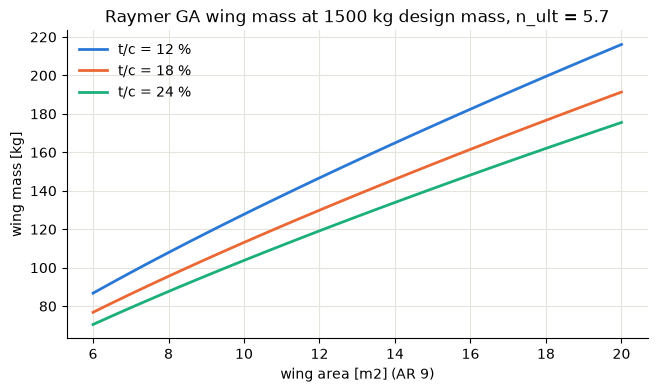

PASS  trend: thicker wing is lighter (t/c exponent -0.3)
PASS  trend: wing mass rises with area


In [4]:
# Trends: wing mass against area and thickness at fixed design mass.
area_m2 = np.linspace(6, 20, 50)
fig, ax = plt.subplots(figsize=(7.5, 4))
for airfoil_name, color in (("naca4412", blue), ("naca4418", orange), ("naca4424", aqua)):
    mass_kg = [float(Wing(area_m2=a, airfoil=asb.Airfoil(airfoil_name)).get_mass_properties(condition).mass)
               for a in area_m2]
    ax.plot(area_m2, mass_kg, color=color, lw=2, label=f"t/c = {airfoil_name[-2:]} %")
ax.set(xlabel="wing area [m2] (AR 9)", ylabel="wing mass [kg]",
       title="Raymer GA wing mass at 1500 kg design mass, n_ult = 5.7")
ax.legend(frameon=False)
plt.show()
thin = float(Wing(airfoil=asb.Airfoil("naca4412")).get_mass_properties(condition).mass)
thick = float(Wing(airfoil=asb.Airfoil("naca4424")).get_mass_properties(condition).mass)
check("trend: thicker wing is lighter (t/c exponent -0.3)", thick < thin)
check("trend: wing mass rises with area",
      float(Wing(area_m2=16).get_mass_properties(condition).mass) > float(Wing().get_mass_properties(condition).mass))

## 3. Assembly: mass and CG aggregation

`Aircraft.get_mass_breakdown` returns one `asb.MassProperties` per physical item;
`total()` is AeroSandbox addition, i.e. mass-weighted CG. The powertrain
installation sums `count x component.get_mass()` per located topology instance
times an installation factor (1.1 in the reference). Items are point masses: no
inertia tensor at this tier.

In [5]:
aircraft = build_reference_aircraft()
breakdown = aircraft.get_mass_breakdown(condition)
items = {f.name: getattr(breakdown, f.name) for f in fields(MassBreakdown)}
total = breakdown.total()
mass_kg = sum(float(i.mass) for i in items.values())
x_cg_m = sum(float(i.mass) * float(i.x_cg) for i in items.values()) / mass_kg
check("aggregation: total mass = sum of items", close(float(total.mass), mass_kg))
check("aggregation: x_cg = mass-weighted mean", close(float(total.x_cg), x_cg_m))
check("aggregation: empty mass = total - payload", close(float(breakdown.mass_empty_kg()), mass_kg - 300.0))

topology = aircraft.powertrain.topology
expected_powertrain_kg = 1.1 * sum(i.count * i.component.get_mass() for i in topology.instances.values())
for installed in aircraft.powertrain.get_instance_mass_properties():
    instance = topology.instances[installed.instance_name]
    print(f"{installed.instance_name:<11} x{instance.count}  {float(installed.mass_properties.mass):7.1f} kg  "
          f"at x = {float(installed.mass_properties.x_cg):.2f} m")
check("powertrain: installed mass = 1.1 x sum(count x get_mass())",
      close(float(breakdown.powertrain.mass), float(expected_powertrain_kg)))

shifted = replace(aircraft, payload=replace(aircraft.payload, x_m=4.0))
delta_m = float(shifted.get_cg_x_m(condition)) - float(total.x_cg)
check("aggregation: moving 300 kg payload 1 m aft shifts CG by 300 / m_total",
      close(delta_m, 300.0 / float(total.mass)))
try:
    replace(aircraft.powertrain, locations=aircraft.powertrain.locations[:-1])
    rejected = False
except ValueError as error:
    rejected = True
    print(f"    ValueError: {error}")
check("powertrain: unlocated instance rejected at construction", rejected)

PASS  aggregation: total mass = sum of items
PASS  aggregation: x_cg = mass-weighted mean
PASS  aggregation: empty mass = total - payload
turboshaft  x1    330.0 kg  at x = 4.60 m
generator   x1    110.0 kg  at x = 4.10 m
battery     x1    176.0 kg  at x = 2.60 m
motor       x4     88.0 kg  at x = 2.79 m
gearbox     x4     44.0 kg  at x = 2.79 m
propulsor   x4    132.0 kg  at x = 2.79 m
PASS  powertrain: installed mass = 1.1 x sum(count x get_mass())
PASS  aggregation: moving 300 kg payload 1 m aft shifts CG by 300 / m_total
    ValueError: Locations must cover every instance exactly; missing ['propulsor'], unknown [].
PASS  powertrain: unlocated instance rejected at construction


## 4. Reference case 1: one-solve mass closure with CG placement

Two caller-owned variables, two explicit equalities:

* `mass_takeoff_kg == breakdown.total().mass` closes the mass loop;
* `x_cg == x_le_wing + 0.25 MAC` places the CG by moving the wing, and the rotor
  strings with it (a reference placement, not a stability criterion: Tier 6).

The closed mass must be a fixed point: rebuilding the aircraft at the solved
wing position and design mass returns the same total.

In [6]:
reference = solve_mass_closure()
for name, mass_kg in reference.component_masses_kg:
    print(f"{name:<16}{mass_kg:8.1f} kg  {100 * mass_kg / reference.mass_takeoff_kg:5.1f} %")
print(f"\nMTOM {reference.mass_takeoff_kg:.2f} kg, empty {reference.mass_empty_kg:.2f} kg, "
      f"wing LE at {reference.x_le_wing_m:.3f} m, CG at {reference.x_cg_m:.3f} m "
      f"({100 * reference.cg_fraction_mac:.2f} % MAC)")
print(f"hover thrust per rotor {reference.thrust_hover_per_rotor_N:.0f} N "
      f"(Tier 3 max at 20 % battery share: about 5284 N; requirements are Tier 7)")

check("closure: residual below 1e-6 kg", abs(reference.closure_residual_kg) < 1e-6)
rebuilt_kg = float(build_reference_aircraft(reference.x_le_wing_m).get_mass(
    StructuralDesignCondition(reference.mass_takeoff_kg)))
check("closure: solved mass is a fixed point of the buildup", close(rebuilt_kg, reference.mass_takeoff_kg, rel=1e-9))
check("closure: CG at 25 % MAC", close(reference.cg_fraction_mac, 0.25, rel=1e-8))
check("closure: item masses sum to MTOM",
      close(sum(m for _, m in reference.component_masses_kg), reference.mass_takeoff_kg, rel=1e-9))
absent_items = ("fuel", "nacelles", "drive_shaft", "equipment")  # fuel from Tier 8; tiltrotor items from Tier 10
check("closure: all item masses positive (no fuel load before Tier 8, no tiltrotor items)",
      all(m > 0 for n, m in reference.component_masses_kg if n not in absent_items)
      and all(dict(reference.component_masses_kg)[n] == 0 for n in absent_items))

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


wing               132.1 kg    8.5 %
horizontal_tail     11.9 kg    0.8 %
vertical_tail        8.9 kg    0.6 %
fuselage            83.2 kg    5.4 %
landing_gear        69.6 kg    4.5 %
systems             66.7 kg    4.3 %
powertrain         880.0 kg   56.7 %
payload            300.0 kg   19.3 %
fuel                 0.0 kg    0.0 %
nacelles             0.0 kg    0.0 %
drive_shaft          0.0 kg    0.0 %
equipment            0.0 kg    0.0 %

MTOM 1552.39 kg, empty 1252.39 kg, wing LE at 3.233 m, CG at 3.521 m (25.00 % MAC)
hover thrust per rotor 3806 N (Tier 3 max at 20 % battery share: about 5284 N; requirements are Tier 7)
PASS  closure: residual below 1e-6 kg
PASS  closure: solved mass is a fixed point of the buildup
PASS  closure: CG at 25 % MAC
PASS  closure: item masses sum to MTOM
PASS  closure: all item masses positive (no fuel load before Tier 8, no tiltrotor items)


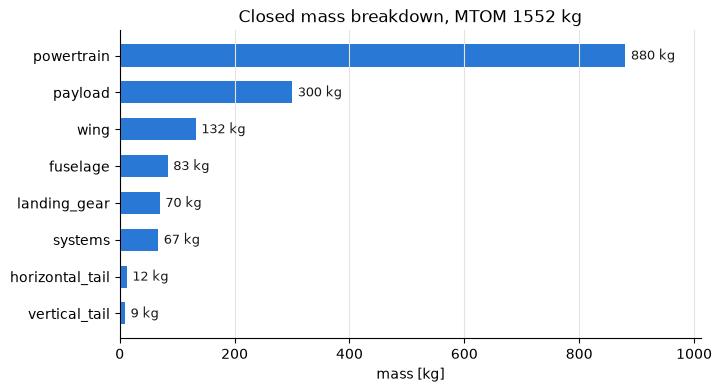

In [7]:
items_kg = sorted(((n, m) for n, m in reference.component_masses_kg if m > 0), key=lambda item: item[1])
names = [n for n, _ in items_kg]
values = [m for _, m in items_kg]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(names, values, color=blue, height=0.6)
for y, v in enumerate(values):
    ax.text(v + 10, y, f"{v:.0f} kg", va="center", fontsize=9, color=ink)
ax.set(xlabel="mass [kg]", xlim=(0, max(values) * 1.15),
       title=f"Closed mass breakdown, MTOM {reference.mass_takeoff_kg:.0f} kg")
ax.grid(axis="y", visible=False)
plt.show()

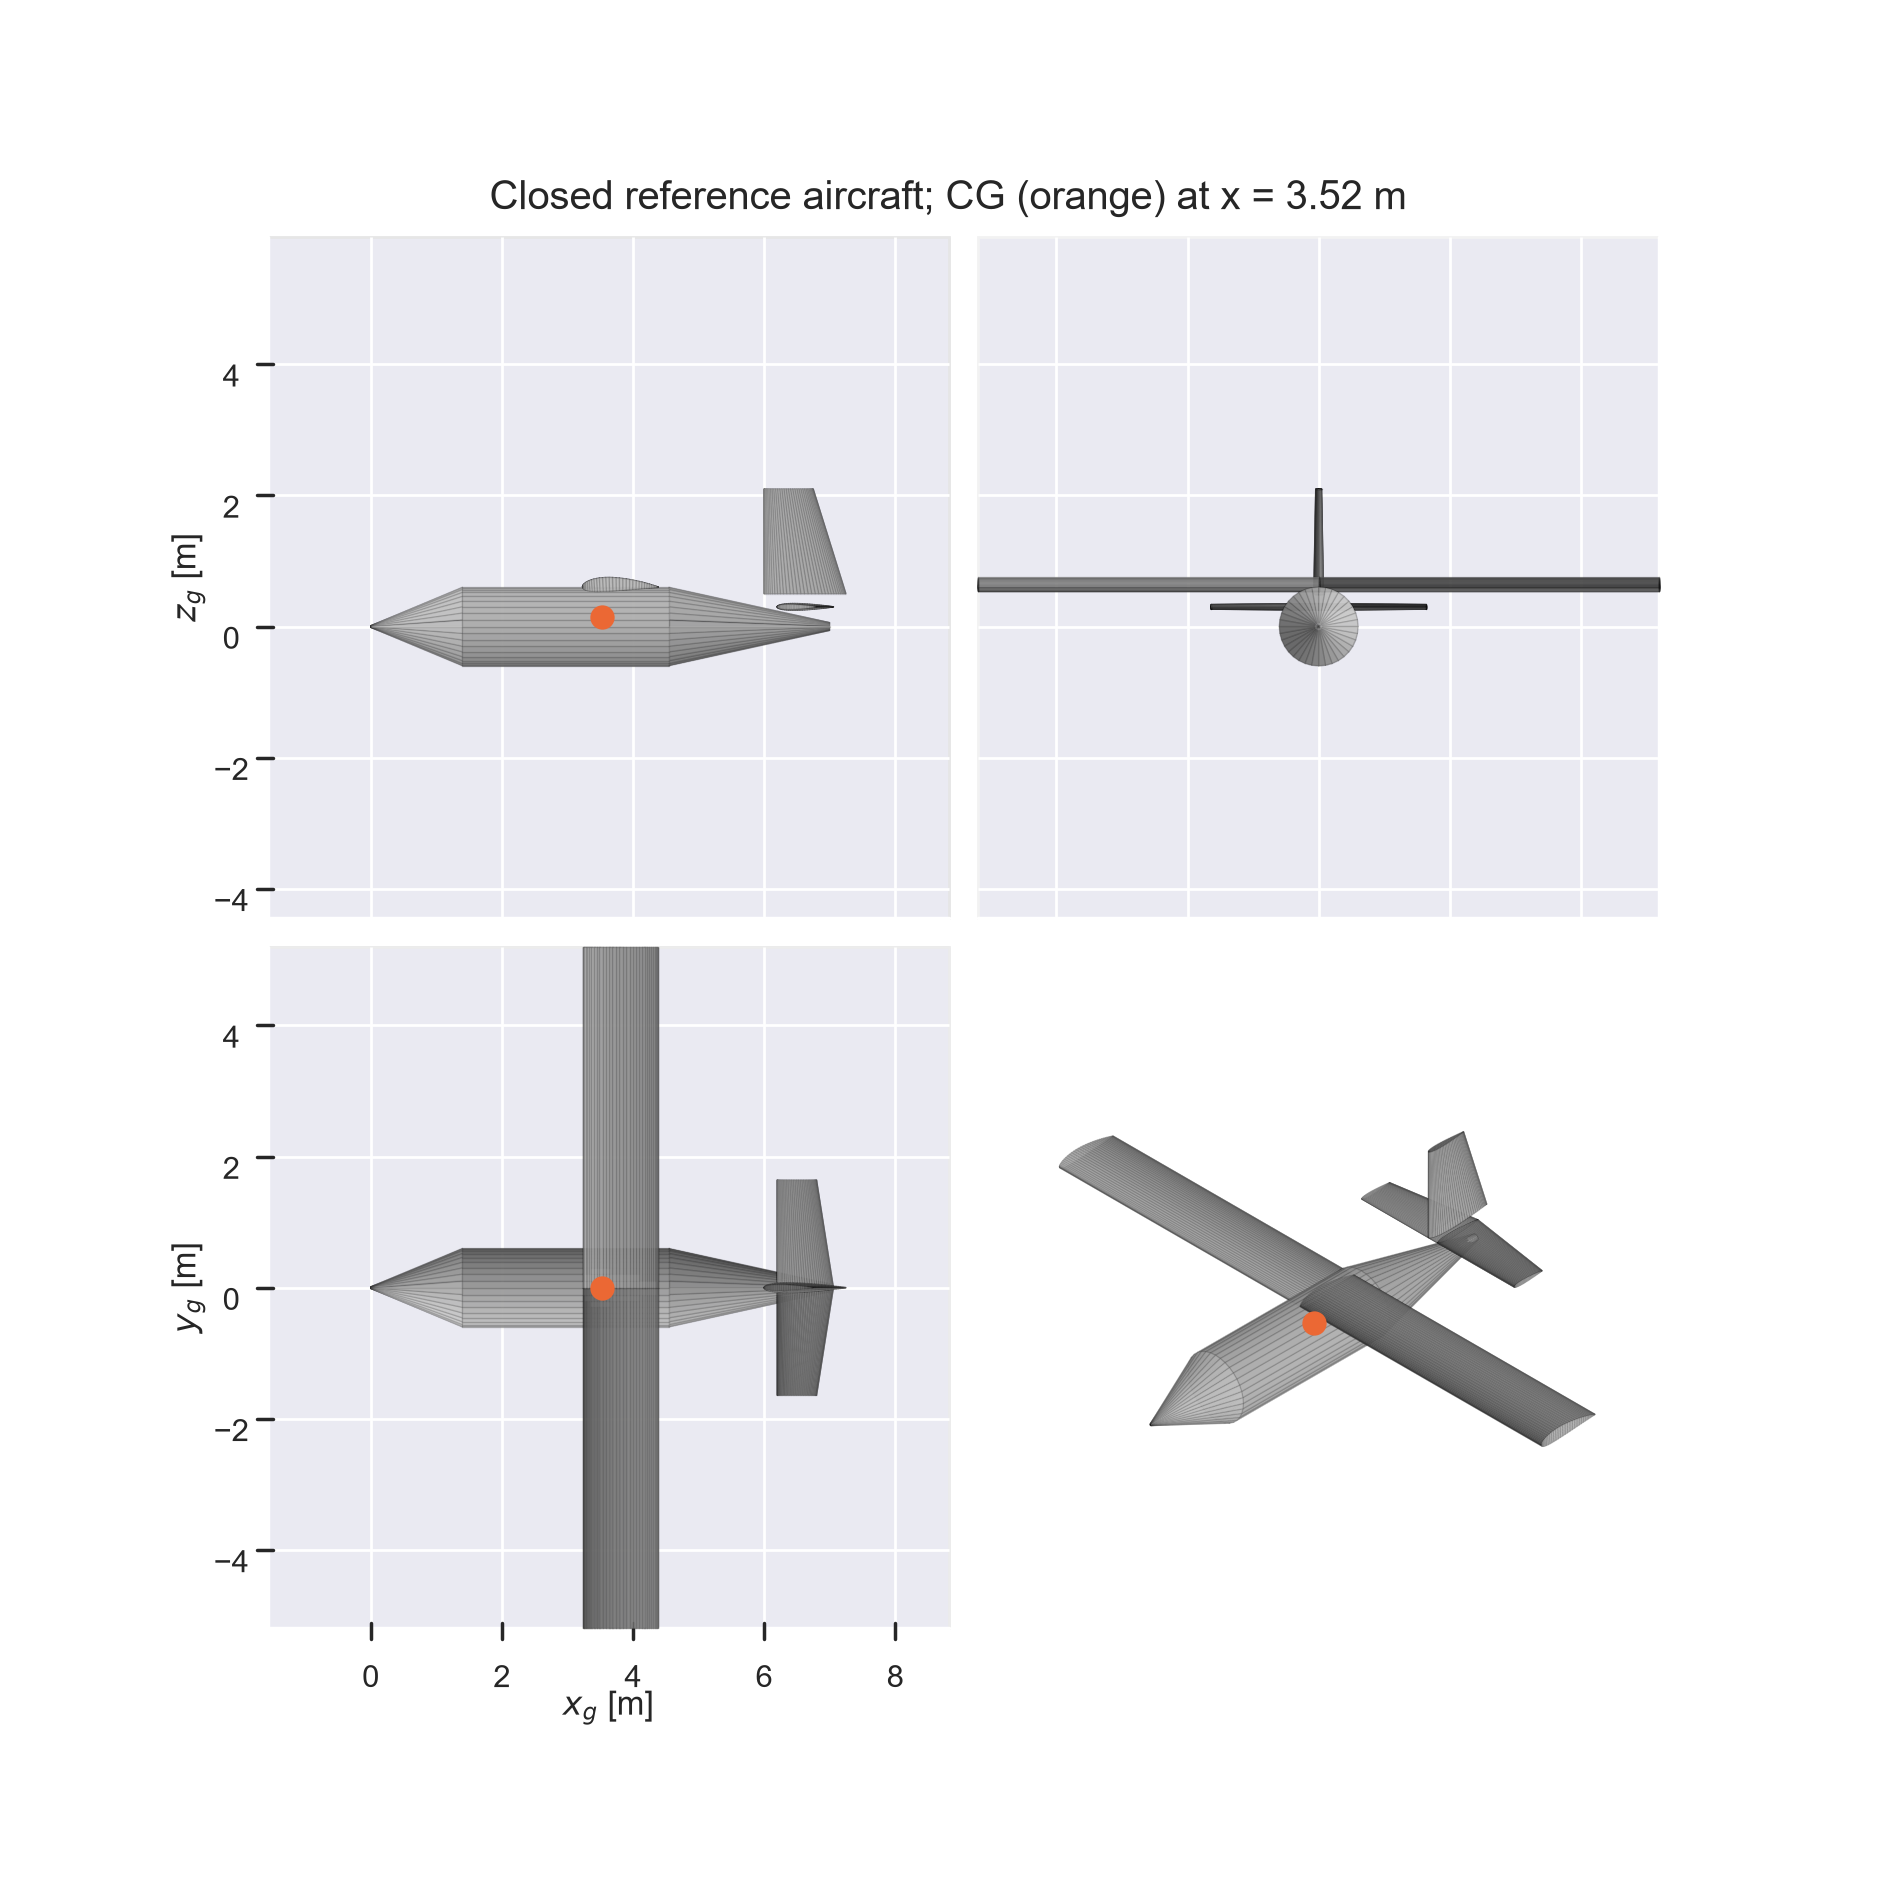

In [8]:
# Three-view of the closed geometry (AeroSandbox drawing) with the CG marked.
# Rotors are not drawn: there is no rotor geometry at this tier. AeroSandbox
# restyles matplotlib globally, so the drawing runs inside an rc_context.
closed = build_reference_aircraft(reference.x_le_wing_m)
closed_breakdown = closed.get_mass_breakdown(StructuralDesignCondition(reference.mass_takeoff_kg))
z_cg_m = float(closed_breakdown.total().z_cg)
with plt.rc_context():
    axs = closed.to_asb().draw_three_view(show=False)
    for ax in (axs[0, 0], axs[1, 0], axs[1, 1]):
        ax.scatter([reference.x_cg_m], [0], [z_cg_m], color=orange, s=60, depthshade=False, zorder=10)
    axs[0, 0].figure.suptitle(f"Closed reference aircraft; CG (orange) at x = {reference.x_cg_m:.2f} m", y=0.98)
    plt.show()

## 5. Reference case 2: payload growth

Every structural correlation depends on the design mass, so 1 kg of payload adds
more than 1 kg of take-off mass. The growth factor $\partial m_{TO}/\partial m_{pay}$
must exceed 1 and MTOM must rise monotonically with payload. The powertrain is
fixed here (ratings are not resized until Tier 9), so its mass is constant.

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


growth factor dMTOM/dpayload: [1.1214 1.1189 1.1166 1.1144 1.1124 1.1105 1.1087 1.107  1.1053 1.1038]
PASS  growth: MTOM rises monotonically with payload
PASS  growth: growth factor exceeds 1 everywhere
PASS  growth: every point closes
PASS  growth: fixed powertrain mass is independent of payload


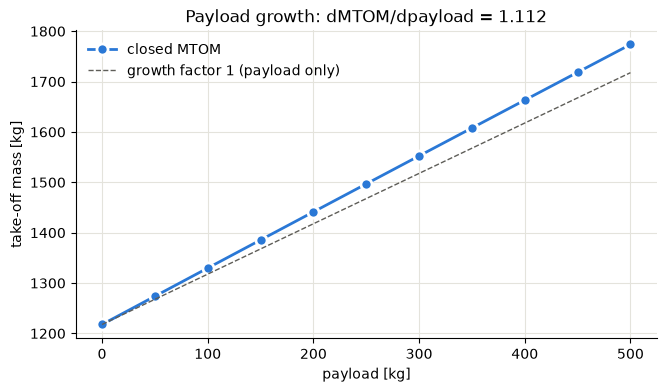

In [9]:
payloads_kg = np.linspace(0, 500, 11)
sweep = [solve_mass_closure(mass_payload_kg=p) for p in payloads_kg]
mtom_kg = np.array([s.mass_takeoff_kg for s in sweep])
growth = np.diff(mtom_kg) / np.diff(payloads_kg)
print("growth factor dMTOM/dpayload:", np.round(growth, 4))
check("growth: MTOM rises monotonically with payload", np.all(np.diff(mtom_kg) > 0))
check("growth: growth factor exceeds 1 everywhere", np.all(growth > 1))
check("growth: every point closes", all(abs(s.closure_residual_kg) < 1e-6 for s in sweep))
powertrain_kg = [dict(s.component_masses_kg)["powertrain"] for s in sweep]
check("growth: fixed powertrain mass is independent of payload", np.ptp(powertrain_kg) < 1e-9)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(payloads_kg, mtom_kg, color=blue, lw=2, marker="o", ms=8, mec="white", mew=2, label="closed MTOM")
ax.plot(payloads_kg, mtom_kg[0] + payloads_kg, color=ink_muted, lw=1, ls="--", label="growth factor 1 (payload only)")
ax.set(xlabel="payload [kg]", ylabel="take-off mass [kg]",
       title=f"Payload growth: dMTOM/dpayload = {growth.mean():.3f}")
ax.legend(frameon=False, loc="upper left")
plt.show()

## 6. Reference case 3: CG placement by wing position

Solving for the wing position at different target CG fractions exercises the
geometry/mass coupling: the wing carries its own mass and all four rotor strings,
so moving it moves the CG as well as the MAC reference. A more aft CG fraction
needs the wing further forward. Take-off mass barely changes, because wing
position enters the masses only through the fuselage's wing-to-tail arm.

In [10]:
fractions = np.linspace(0.15, 0.35, 5)
placements = [solve_mass_closure(cg_fraction_mac=f) for f in fractions]
for f, p in zip(fractions, placements):
    print(f"target {100 * f:4.1f} % MAC: wing LE {p.x_le_wing_m:.3f} m, CG {p.x_cg_m:.3f} m, MTOM {p.mass_takeoff_kg:.1f} kg")
check("placement: every target fraction is met", all(close(p.cg_fraction_mac, f, rel=1e-8) for f, p in zip(fractions, placements)))
x_le_m = np.array([p.x_le_wing_m for p in placements])
check("placement: aft CG target moves the wing forward", np.all(np.diff(x_le_m) < 0))
check("placement: MTOM nearly independent of wing position (only fuselage tail arm changes)",
      np.ptp([p.mass_takeoff_kg for p in placements]) / reference.mass_takeoff_kg < 0.01)

target 15.0 % MAC: wing LE 3.388 m, CG 3.561 m, MTOM 1552.7 kg
target 20.0 % MAC: wing LE 3.310 m, CG 3.541 m, MTOM 1552.5 kg
target 25.0 % MAC: wing LE 3.233 m, CG 3.521 m, MTOM 1552.4 kg
target 30.0 % MAC: wing LE 3.155 m, CG 3.502 m, MTOM 1552.3 kg
target 35.0 % MAC: wing LE 3.078 m, CG 3.482 m, MTOM 1552.1 kg
PASS  placement: every target fraction is met
PASS  placement: aft CG target moves the wing forward
PASS  placement: MTOM nearly independent of wing position (only fuselage tail arm changes)


## 7. Symbolic compatibility and architectural boundaries

Geometry and design mass can be Opti variables throughout. The vehicle layer
depends on the powertrain layer, never the reverse, and neither the vehicle
modules nor the assembly reference the Opti API: the closure equality lives in
the caller.

In [11]:
opti = asb.Opti()
area_m2 = opti.variable(init_guess=12, lower_bound=1)
mass_design_kg = opti.variable(init_guess=1500, lower_bound=100)
symbolic_wing = Wing(area_m2=area_m2).get_mass_properties(StructuralDesignCondition(mass_design_kg))
check("symbolic: wing mass with variable area and design mass is CasADi MX", isinstance(symbolic_wing.mass, cas.MX))
symbolic_total = build_reference_aircraft(opti.variable(init_guess=2.5)).get_mass_breakdown(
    StructuralDesignCondition(mass_design_kg)).total()
check("symbolic: aircraft total mass and CG are CasADi MX",
      isinstance(symbolic_total.mass, cas.MX) and isinstance(symbolic_total.x_cg, cas.MX))

package = repo_root / "src/aircraft_closure"
optimization_names = {"Opti", "variable", "subject_to", "solve", "minimize", "parameter"}


def imports_of(path):
    tree = ast.parse(path.read_text(encoding="utf-8"))
    names = {a.name for n in ast.walk(tree) if isinstance(n, ast.Import) for a in n.names}
    names |= {(n.module or "") for n in ast.walk(tree) if isinstance(n, ast.ImportFrom)}
    return tree, names


for path in sorted((package / "powertrain").rglob("*.py")) + sorted((package / "core").glob("*.py")):
    _, names = imports_of(path)
    check(f"boundaries: {path.relative_to(package).as_posix()} does not import vehicle",
          not any("vehicle" in name for name in names))
for path in sorted((package / "vehicle").glob("*.py")):
    tree, _ = imports_of(path)
    used = {n.id for n in ast.walk(tree) if isinstance(n, ast.Name)}
    used |= {n.attr for n in ast.walk(tree) if isinstance(n, ast.Attribute)}
    check(f"boundaries: vehicle/{path.name} references no Opti API", not used & optimization_names)

PASS  symbolic: wing mass with variable area and design mass is CasADi MX


PASS  symbolic: aircraft total mass and CG are CasADi MX
PASS  boundaries: powertrain/__init__.py does not import vehicle
PASS  boundaries: powertrain/compatibility.py does not import vehicle
PASS  boundaries: powertrain/components/__init__.py does not import vehicle
PASS  boundaries: powertrain/components/battery.py does not import vehicle
PASS  boundaries: powertrain/components/gearbox.py does not import vehicle
PASS  boundaries: powertrain/components/generator.py does not import vehicle
PASS  boundaries: powertrain/components/motor.py does not import vehicle
PASS  boundaries: powertrain/components/propulsor.py does not import vehicle
PASS  boundaries: powertrain/components/rotor.py does not import vehicle
PASS  boundaries: powertrain/components/turboshaft.py does not import vehicle
PASS  boundaries: powertrain/decks.py does not import vehicle
PASS  boundaries: powertrain/ports.py does not import vehicle
PASS  boundaries: powertrain/topologies.py does not import vehicle
PASS  boundar

## 8. Summary and unit test suite

In [12]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

64 / 64 notebook checks passed


In [13]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 261 tests in 27.886s

OK
